<a href="https://colab.research.google.com/github/CesarAr0504/Arredondo_Restrepo_Lab_Sen/blob/main/Practica_4_Introducci%C3%B3n_a_los_biopotenciales_y_adquisici%C3%B3n_de_se%C3%B1ales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Practica 4: Introducción a los biopotenciales y adquisición de señales ECG y EMG**



*   Cesar Eduardo Arredondo
*   Alejandro Restrepo Molina



###**Importaciones e instalaciones previas**

In [ ]:
!pip install neurokit2
!pip install hrv-analysis
!pip install py-ecg-detectors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.5/554.5 kB 13.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for gatspy: filename=gatspy-0.3-py3-none-any.whl size=43804 sha256=d932b2acf36dfbfb5755a566d78f5051dc31404a4689465b4e329d77979f7efc
  Stored in directory: /root/.cache/pip/wheels/b5/56/88/04643e9be584a6018e10aae5789d98225995da3e89513c3f30
Successfully built gatspy


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from ecgdetectors import Detectors
import neurokit2 as nk
import astropy.stats
from astropy.timeseries import LombScargle
astropy.stats.LombScargle = LombScargle
from hrvanalysis import get_time_domain_features

## **1.**

**Realice un esquema donde se describan y expliquen las diferentes etapas del registro de biopotenciales, desde la generación de los potenciales de acción hasta su adquisición por el equipo.**


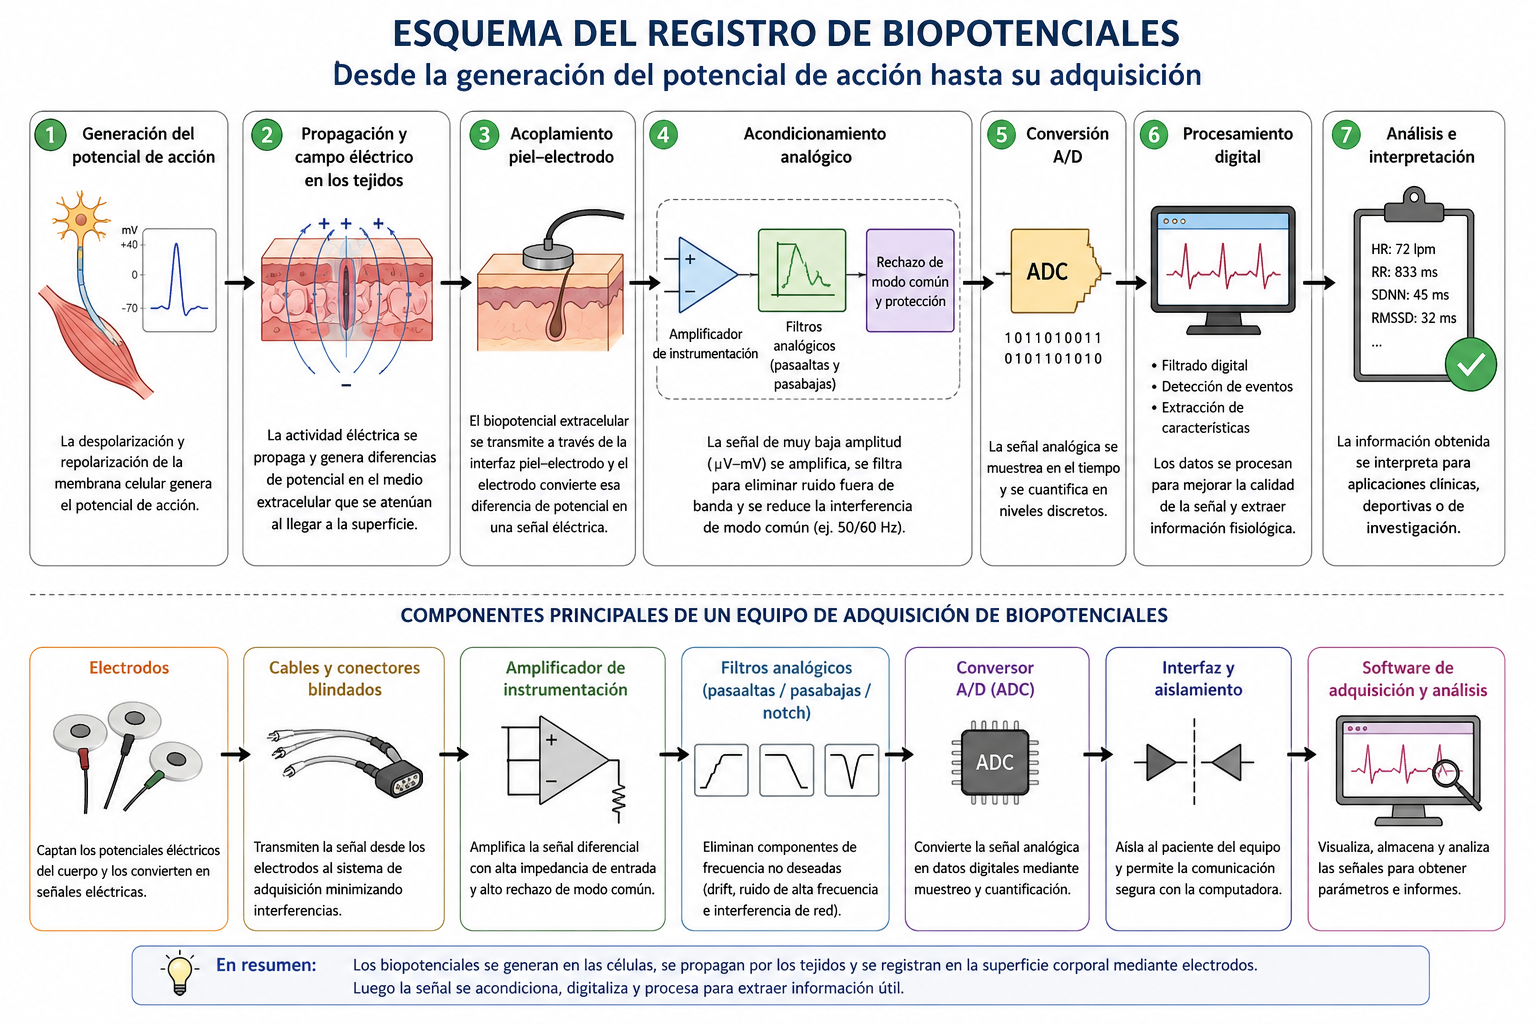

##**2.**

**Presente una tabla con las principales fuentes de ruido en el registro de biopotenciales.**

**Determine ¿Cuáles de estas fuentes de ruido son estáticas o variantes en el tiempo? Indique que estrategias se utilizan para controlar o eliminar dicha fuente de ruido**

In [ ]:
# @title
data = {
    "Fuente de ruido": [
        "Red 50/60 Hz", "Movimiento electrodos", "Impedancia piel-electrodo",
        "Ruido térmico", "Interferencia EM", "Artefacto muscular",
        "Deriva línea base", "Cuantificación ADC"
    ],
    "Naturaleza": [
        "Electromagnético", "Mecánico", "Electroquímico",
        "Electrónico", "Electromagnético", "Fisiológico",
        "Electroquímico", "Digital"
    ],
    "Tipo": [
        "Variable", "Variable", "Variable",
        "Estático", "Variable", "Variable",
        "Variable lenta", "Estático"
    ],
    "Control": [
        "Notch, blindaje", "Fijación", "Gel, limpieza",
        "Diseño circuito", "Blindaje", "Reposo",
        "Filtro pasaaltas", "Mayor resolución"
    ]
}

df = pd.DataFrame(data)
df

,Fuente de ruido,Naturaleza,Tipo,Control
0,Red 50/60 Hz,Electromagnético,Variable,"Notch, blindaje"
1,Movimiento electrodos,Mecánico,Variable,Fijación
2,Impedancia piel-electrodo,Electroquímico,Variable,"Gel, limpieza"
3,Ruido térmico,Electrónico,Estático,Diseño circuito
4,Interferencia EM,Electromagnético,Variable,Blindaje
5,Artefacto muscular,Fisiológico,Variable,Reposo
6,Deriva línea base,Electroquímico,Variable lenta,Filtro pasaaltas
7,Cuantificación ADC,Digital,Estático,Mayor resolución


##**3.**

**Describa ¿Cuál es la problemática asociada al acoplamiento piel-electrodo? ¿Cuáles estrategias se utilizan para mejorarla? Además, responda ¿Por qué el acoplamiento piel-electrodo constituye la etapa más crítica en el registro de señales de superficie (sEMG, EEG, ECG)?**

El acoplamiento piel-electrodo es una de las etapas más problemáticas del registro porque la piel no es un conductor ideal. La capa córnea de la epidermis actúa como una barrera de alta impedancia, y la interfaz entre la piel y el electrodo presenta comportamiento resistivo, capacitivo y electroquímico. Esto produce caída de amplitud, distorsión de fase, deriva de la línea base y aumento del ruido. Además, la interfaz puede ser inestable si hay sudor, movimiento, mala preparación de la piel o presión insuficiente del electrodo.

Las estrategias más usadas para mejorar esta interfaz son: limpieza de la piel con alcohol o abrasión suave, reducción del vello, uso de gel o pasta conductora, elección de electrodos adecuados, presión constante de contacto, tiempo de estabilización antes del registro, y uso de amplificadores con alta impedancia de entrada. En algunos casos también se recurre a electrodos Ag/AgCl, que ofrecen mejor estabilidad electroquímica que otros materiales.

##**4.**

**Análisis de la Variabilidad de la frecuencia cardíaca (HRV)**

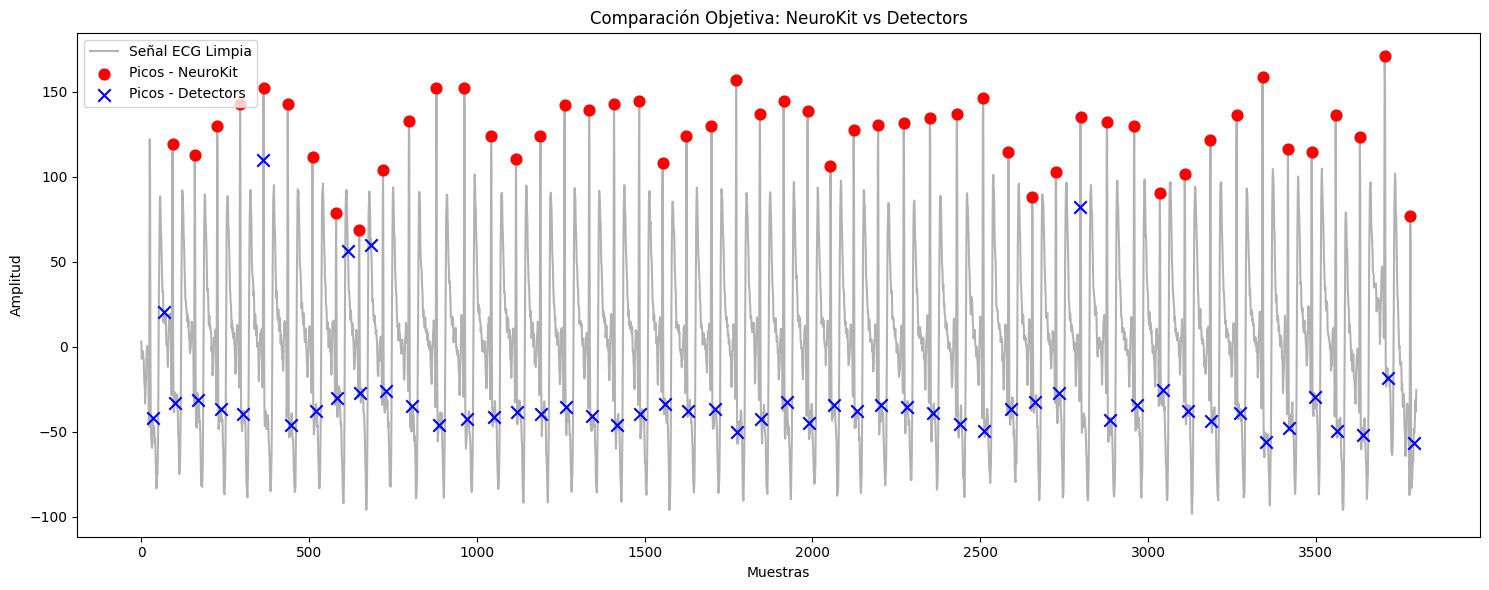

Total picos detectados por NeuroKit: 51
Total picos detectados por Detectors: 55


In [ ]:
df = pd.read_csv('ecg1.csv', header=None)
ecg_signal = df.values.flatten()
fs = 100

ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=fs, method="neurokit")

t_corte = 2  # segundos a eliminar
inicio = int(t_corte * fs)
ecg_cleaned = ecg_cleaned[inicio:]
ecg_cleaned = -ecg_cleaned # Señal invertida y lista

# --- Algoritmo A: NeuroKit ---
_, info_nk = nk.ecg_peaks(ecg_cleaned, sampling_rate=fs, method="neurokit")
picos_nk = info_nk["ECG_R_Peaks"]

# --- Algoritmo B: Detectors ---
# Inicializamos el detector con nuestra frecuencia de muestreo
detectores = Detectors(fs)
# Usamos el algoritmo de Pan-Tompkins
picos_det = detectores.pan_tompkins_detector(ecg_cleaned)

plt.figure(figsize=(15, 6))
plt.plot(ecg_cleaned, label="Señal ECG Limpia", color='gray', alpha=0.6)

# Graficamos los picos de NeuroKit
plt.scatter(picos_nk, ecg_cleaned[picos_nk], color='red', marker='o', s=60, label='Picos - NeuroKit', zorder=5)

# Graficamos los picos de Detectors
plt.scatter(picos_det, ecg_cleaned[picos_det], color='blue', marker='x', s=80, label='Picos - Detectors', zorder=6)

plt.title("Comparación Objetiva: NeuroKit vs Detectors")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.legend()
plt.tight_layout()
plt.show()

# Imprimimos los totales para el informe
print(f"Total picos detectados por NeuroKit: {len(picos_nk)}")
print(f"Total picos detectados por Detectors: {len(picos_det)}")

Ahora se va a cuantificar su variabilidad, además, se hace uso de la librería hrvanalisis para extraer su variabilidad. Mas específicamente se utiliza la función get_time_domain_features, la cual es una herramienta de procesamiento que toma de intervalos RR (tiempo entre latidos) y extrae métricas de como varia el ritmo cardiaco en el tiempo. Entre las métricas mas importantes que entrega la función tenemos[1]:


*   **mean_nni:** Es el promedio de todos los intervalos RR.

*   **sdnn:** Es la desviación estándar de los intervalos. Un SDNN alto indica que el corazón esta en buenas condiciones de salud, mientras que un SDNN bajo suele indicar fatiga del sistema.

* **rmssd:** Es la raíz cuadrada de la media de las diferencias al cuadrado entre latidos adyacentes. Es el indicador más fiable de la actividad parasimpática.

* **sdsd:** Desviación estándar de las diferencias sucesivas.

* **nn50:** Cuenta cuántas veces la diferencia entre un latido y el siguiente fue mayor a 50 milisegundos.

* **pnn50:** Es el porcentaje que representa el nn50 sobre el total de latidos. Si es alto, significa que el ritmo cardíaco cambia con mucha frecuencia y rapidez, lo cual es típico de una buena salud vagal.



In [ ]:
def hrv_time(rr):#Vamos a hacer una función manual para calcular el hrv
    rr = np.array(rr)
    sdnn = np.std(rr)
    rmssd = np.sqrt(np.mean(np.diff(rr)**2))
    nn50 = np.sum(np.abs(np.diff(rr)) > 50)
    pnn50 = nn50 / len(rr)
    hr_mean = 60000 / np.mean(rr)

    return {
        "mean_nni": np.mean(rr),
        "sdnn": sdnn,
        "rmssd": rmssd,
        "nn50": nn50,
        "pnn50": pnn50,
        "hr_mean": hr_mean
    }

#Calculamos el intervalo en milisegundos
rr_nk_ms = np.diff(picos_nk) * (1000 / fs)
rr_det_ms = np.diff(picos_det) * (1000 / fs)

print("\n=== HRV (NeuroKit por Función Manual) ===")
features_nk = hrv_time(rr_nk_ms) #Pasamos el tiempo, no la amplitud
for k, v in features_nk.items():
    print(f"{k}: {round(v, 2)}")

print("\n=== HRV (Detectors por Función Manual) ===")
features_det = hrv_time(rr_det_ms)
for k, v in features_det.items():
    print(f"{k}: {round(v, 2)}")

print("\n=== HRV (NeuroKit por Librería hrvanalysis) ===")
# Usamos los intervalos de NeuroKit para validar si la función manual da lo mismo que la librería
features_lib = get_time_domain_features(rr_nk_ms)
for k, v in features_lib.items():
    if v is not None:
        print(f"{k}: {round(v, 2)}")


=== HRV (NeuroKit - Tu Función Manual) ===
mean_nni: 737.4
sdnn: 39.33
rmssd: 29.14
nn50: 4
pnn50: 0.08
hr_mean: 81.37

=== HRV (Detectors - Tu Función Manual) ===
mean_nni: 695.56
sdnn: 134.55
rmssd: 113.98
nn50: 31
pnn50: 0.57
hr_mean: 86.26

=== HRV (NeuroKit - Librería hrvanalysis) ===
mean_nni: 737.4
sdnn: 39.73
sdsd: 29.07
nni_50: 4
pnni_50: 8.16
nni_20: 17
pnni_20: 34.69
rmssd: 29.14
median_nni: 735.0
range_nni: 170.0
cvsd: 0.04
cvnni: 0.05
mean_hr: 81.6
max_hr: 90.91
min_hr: 72.29
std_hr: 4.3


#**5.**

**Consulte tres aplicaciones clínicas del uso de ECG y EMG (seis aplicaciones en total, tres por cada tipo de señal), el tipo de registro y procesamiento que se utiliza en cada una de ellas.**

**Aplicaciones ECG:**

*   **Monitoreo de Arritmias:** La ECG permite la detección de irregularidades en el ritmo cardíaco (taquicardias, bradicardias o latidos ectópicos) durante periodos largos. Esto utilizando un registro ambulatorio y continuo (24 horas) con electrodos de superficie. Mediante un procesamiento que utiliza la detección de picos R y análisis de variabilidad (HRV) para identificar intervalos RR anómalos[2].

*   **Prueba de Esfuerzo (Ergometría):** La ECG abre las puertas a la evaluación de la respuesta del corazón ante el estrés físico para detectar una isquemia miocárdica o enfermedad coronaria. Esto mediante un registro en tiempo real (dinámico) mientras el paciente realiza ejercicio (caminadora o bicicleta). El procesamiento de la señal se hace por filtros adaptativos para eliminar ruido por movimiento y seguimiento de la elevación/depresión del segmento ST[3].

* **Diagnóstico de Infarto (UCI):** La ECG permite la identificación inmediata de daños en el tejido cardiaco mediante cambios en la morfología eléctrica del corazón. Esto gracias a un registro continuo en reposo mediante 12 derivaciones estándar en monitor de cabecera. El procesamiento se da por reconocimiento de patrones para detectar cambios en la onda T y el complejo QRS en comparación con una línea base[4].

**Aplicaciones EMG:**

*  **Control de Prótesis Biónicas:** Uso de señales musculares para comandar el movimiento de extremidades artificiales en pacientes con amputaciones. Se da un registro de superficie (sEMG) sobre los músculos remanentes del miembro afectado. El procesamiento se da haciendo el cálculo de la envolvente (RMS) para traducir la intensidad de la contracción en grados de libertad del motor[5].

*  **Diagnóstico Neuromuscular:** La EMG permite la diferenciación entre enfermedades del músculo (miopatías) y problemas de los nervios que los controlan (neuropatías). Esto mediante un registro invasivo mediante electrodos de aguja insertados directamente en el vientre muscular. El procesamiento consta del análisis de frecuencia (FFT) para evaluar la tasa de disparo y la morfología de las unidades motoras[6].

*  **Rehabilitación del Suelo Pélvico:** Consta de un entrenamiento de fuerza y coordinación muscular mediante retroalimentación visual para el paciente (Biofeedback). Se da un registro de superficie o intracavitario (no invasivo) para medir la activación voluntaria. El procesamiento consiste en la integración de la señal (iEMG) para cuantificar el esfuerzo total y el área bajo la curva de contracción[7].

##**6.**

**Adjunte al menos tres conclusiones, y referencias bibliográficas apropiadas y suficientes (evitar el uso de páginas web y preferir el uso de artículos académicos)**

* Al comparar los resultados, se observa una diferencia significativa entre los algoritmos. Mientras que NeuroKit detectó variaciones más sutiles y realistas (SDNN de 39.73 ms), el método de Detectors (Pan-Tompkins) arrojó una variabilidad inusualmente alta (SDNN de 134.55 ms). Esto sugiere que, para esta señal específica, el algoritmo de NeuroKit fue más robusto frente al ruido residual, mientras que Detectors pudo haber incurrido en falsos positivos, alterando drásticamente las métricas de variabilidad cardíaca. Esta conclusion tambien se confirma al ver la grafica de los picos detectados por ambos algoritmos.

* Se determinó que la correcta orientación de la señal es fundamental para el éxito del procesamiento digital. Inicialmente, la captura presentaba los picos R invertidos debido a la polaridad de los electrodos, lo que impedía una detección automática correcta. La implementación de la inversión matemática de la señal (`ecg_cleaned = -ecg_cleaned`), sumada al recorte de los primeros 2 segundos de ruido de estabilización del sensor, permitió estabilizar la línea base y normalizar la morfología del complejo QRS para un análisis fiable.

* Los resultados obtenidos (RMSSD de 29.14 ms y frecuencia cardíaca de 81.6 BPM) son consistentes con los valores normativos para un adulto joven en reposo[8]. Un RMSSD superior a 25 ms y un pNN50 del 8.16% indican una regulación autonómica saludable, donde el sistema nervioso parasimpático tiene un control adecuado sobre el ritmo cardíaco, validando que la señal capturada por el sensor refleja un estado fisiológico real y no puramente ruido.

**Bibliografia:**

[1]R. Champseix et al., "HRV Analysis: A Python library for Heart Rate Variability analysis," Aura Healthcare, [En línea]. Disponible en: https://aura-healthcare.github.io/hrv-analysis/hrvanalysis.html

[2]R. M. Robertson et al., "Recommendations for the Standardization and Interpretation of the Electrocardiogram: Part I," Circulation, vol. 115, no. 10, pp. 1306–1324, mar. 2007. doi: 10.1161/CIRCULATIONAHA.106.180200.

[3]G. F. Fletcher et al., "Exercise Standards for Testing and Training: A Scientific Statement From the American Heart Association," Circulation, vol. 128, no. 8, pp. 873–934, ago. 2013. doi: 10.1161/CIR.0b013e31829b5b44.

[4]K. Thygesen et al., "Fourth Universal Definition of Myocardial Infarction," Circulation, vol. 138, no. 20, pp. e618–e651, nov. 2018. doi: 10.1161/CIR.0000000000000617.

[5]D. Farina y O. C. Aszmann, "Bionic limbs: Clinical practice and development," Science Direct / PubMed, sep. 2014. [En línea]. Disponible en: https://pubmed.ncbi.nlm.nih.gov/25298319/

[6]E. Criswell, Cram's Introduction to Surface Electromyography, 2da ed. Jones & Bartlett Publishers, 2010. [En línea]. Disponible en: https://samples.jblearning.com/9780763732745/32745_FMXX_Final.pdf

[7]P. S. Hamilton, "Open Source ECG Analysis Software Documentation," PMC, 2002. [En línea]. Disponible en: https://pmc.ncbi.nlm.nih.gov/articles/PMC2323522/

[8]D. Nunan, G. R. Sandercock, y D. A. Brodie, "A Quantitative Systematic Review of Normal Values for Short-Term Heart Rate Variability in Healthy Adults," Pacing and Clinical Electrophysiology, vol. 33, no. 11, pp. 1407–1417, nov. 2010. doi: 10.1111/j.1540-8159.2010.02841.x.